In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, 
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, 
                                            download=True, transform=transform)

# Split train into train + validation
train_size = 50000
val_size = 10000
train_set, val_set = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_dataset)}")

Using device: cuda
Train: 50000, Val: 10000, Test: 10000


In [50]:
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  
        self.conv3 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pool  = nn.MaxPool2d(2)                            
        self.relu  = nn.ReLU()
        self.fc1   = nn.Linear(64 * 7 * 7, 8)
        self.fc2   = nn.Linear(8, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  
        x = self.pool(self.relu(self.conv2(x)))  
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)               
        x = self.relu(self.fc1(x))               
        x = self.fc2(x)                          
        return x

model = MnistCNN().to(device)

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total}")

Total parameters: 48482


In [51]:
images,labels = next(iter(train_loader))

print(f"batch shape:{images.shape}")

batch shape:torch.Size([64, 1, 28, 28])


In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate(loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/30 | Train Loss: 0.5588, Train Acc: 0.8266 | Val Loss: 0.1799, Val Acc: 0.9511
Epoch 2/30 | Train Loss: 0.1474, Train Acc: 0.9614 | Val Loss: 0.1098, Val Acc: 0.9699
Epoch 3/30 | Train Loss: 0.0997, Train Acc: 0.9733 | Val Loss: 0.0890, Val Acc: 0.9733
Epoch 4/30 | Train Loss: 0.0777, Train Acc: 0.9794 | Val Loss: 0.0794, Val Acc: 0.9791
Epoch 5/30 | Train Loss: 0.0599, Train Acc: 0.9831 | Val Loss: 0.0563, Val Acc: 0.9844
Epoch 6/30 | Train Loss: 0.0410, Train Acc: 0.9878 | Val Loss: 0.0451, Val Acc: 0.9879
Epoch 7/30 | Train Loss: 0.0305, Train Acc: 0.9908 | Val Loss: 0.0389, Val Acc: 0.9898
Epoch 8/30 | Train Loss: 0.0254, Train Acc: 0.9921 | Val Loss: 0.0455, Val Acc: 0.9874
Epoch 9/30 | Train Loss: 0.0210, Train Acc: 0.9931 | Val Loss: 0.0482, Val Acc: 0.9869
Epoch 10/30 | Train Loss: 0.0184, Train Acc: 0.9944 | Val Loss: 0.0445, Val Acc: 0.9886
Epoch 11/30 | Train Loss: 0.0157, Train Acc: 0.9949 | Val Loss: 0.0490, Val Acc: 0.9871
Epoch 12/30 | Train Loss: 0.0148, Train A

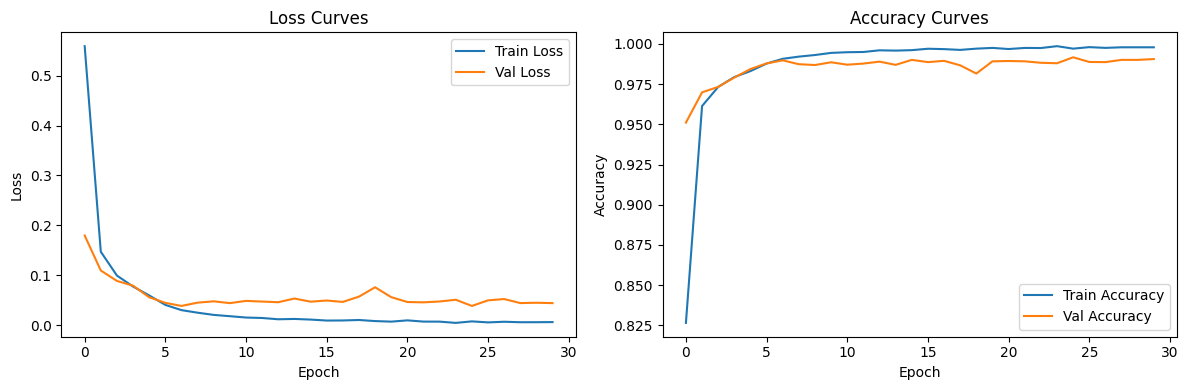

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('mnist_curves.png', dpi=150)
plt.show()

In [54]:
test_loss,test_acc = evaluate(test_loader)
print(f"Test Accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

Test Accuracy: 0.9905, Test loss: 0.0398


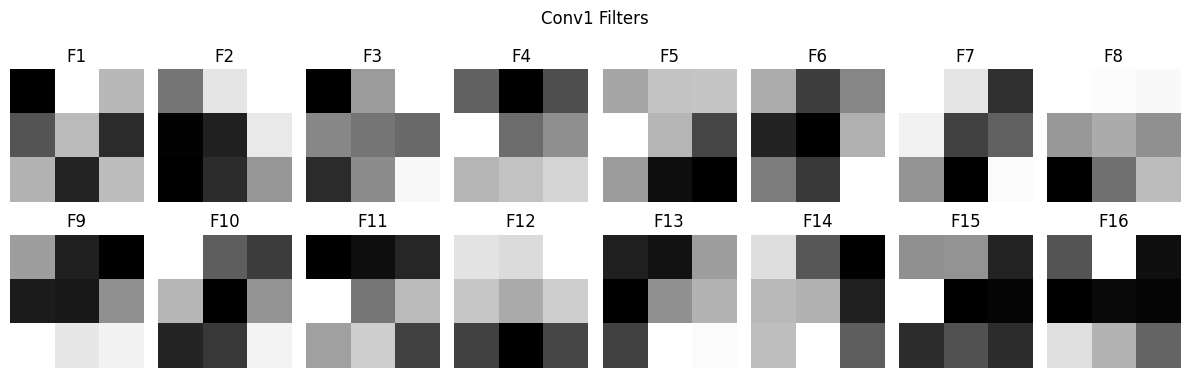

In [55]:
filters = model.conv1.weight.data.cpu()  

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='gray')
    ax.axis('off')
    ax.set_title(f'F{i+1}')

plt.suptitle('Conv1 Filters')
plt.tight_layout()
plt.savefig('filters.png', dpi=150)
plt.show()

In [56]:
train_data = torch.load('./cmnist/train_biased.pt')
test_biased = torch.load('./cmnist/test_biased.pt')
test_unbiased = torch.load('./cmnist/test_unbiased.pt')

print(type(train_data))
print(train_data.keys() if isinstance(train_data,dict)else train_data)

<class 'tuple'>
(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [57]:
images,labels = train_data
print(f"Image shape: {images.shape}, label shape: {labels.shape}")
print(f"label example: {labels[:10]}")

Image shape: torch.Size([60000, 3, 28, 28]), label shape: torch.Size([60000])
label example: tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


In [58]:
from torch.utils.data import TensorDataset, DataLoader

train_images, train_labels = torch.load('./cmnist/train_biased.pt')
test_bias_images, test_bias_labels = torch.load('./cmnist/test_biased.pt')
test_unbias_images, test_unbias_labels = torch.load('./cmnist/test_unbiased.pt')

train_cmnist = TensorDataset(train_images, train_labels)
test_bias_cmnist = TensorDataset(test_bias_images, test_bias_labels)
test_unbias_cmnist = TensorDataset(test_unbias_images, test_unbias_labels)

train_cmnist_loader = DataLoader(train_cmnist, batch_size=64, shuffle=True)
test_bias_loader = DataLoader(test_bias_cmnist, batch_size=64, shuffle=False)
test_unbias_loader = DataLoader(test_unbias_cmnist, batch_size=64, shuffle=False)

print(f"Train: {len(train_cmnist)}, Biased Test: {len(test_bias_cmnist)}, Unbiased Test: {len(test_unbias_cmnist)}")

Train: 60000, Biased Test: 10000, Unbiased Test: 10000


In [59]:
class CMnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  
        self.conv3 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pool  = nn.MaxPool2d(2)                              
        self.relu  = nn.ReLU()
        self.fc1   = nn.Linear(64 * 7 * 7, 8)
        self.fc2   = nn.Linear(8, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  
        x = self.pool(self.relu(self.conv2(x)))  
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)               
        x = self.relu(self.fc1(x))               
        x = self.fc2(x)                          
        return x

cmodel = CMnistCNN().to(device)

total = sum(p.numel() for p in cmodel.parameters())
print(f"Total parameters: {total}")

Total parameters: 48770


In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cmodel.parameters(), lr=0.001,weight_decay=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate_cmodel(loader):
    cmodel.eval()
    correct, total, running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cmodel(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

num_epochs = 30

for epoch in range(num_epochs):
    cmodel.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_cmnist_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cmodel(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_cmnist_loader)
    train_acc = correct / total
    # val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    # val_losses.append(val_loss)
    train_accs.append(train_acc)
    # val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

Epoch 1/30 | Train Loss: 0.2975, Train Acc: 0.9178
Epoch 2/30 | Train Loss: 0.0708, Train Acc: 0.9801
Epoch 3/30 | Train Loss: 0.0450, Train Acc: 0.9869
Epoch 4/30 | Train Loss: 0.0349, Train Acc: 0.9899
Epoch 5/30 | Train Loss: 0.0280, Train Acc: 0.9917
Epoch 6/30 | Train Loss: 0.0231, Train Acc: 0.9929
Epoch 7/30 | Train Loss: 0.0194, Train Acc: 0.9941
Epoch 8/30 | Train Loss: 0.0169, Train Acc: 0.9945
Epoch 9/30 | Train Loss: 0.0136, Train Acc: 0.9959
Epoch 10/30 | Train Loss: 0.0131, Train Acc: 0.9958
Epoch 11/30 | Train Loss: 0.0129, Train Acc: 0.9960
Epoch 12/30 | Train Loss: 0.0095, Train Acc: 0.9970
Epoch 13/30 | Train Loss: 0.0100, Train Acc: 0.9969
Epoch 14/30 | Train Loss: 0.0092, Train Acc: 0.9972
Epoch 15/30 | Train Loss: 0.0082, Train Acc: 0.9976
Epoch 16/30 | Train Loss: 0.0080, Train Acc: 0.9970
Epoch 17/30 | Train Loss: 0.0078, Train Acc: 0.9975
Epoch 18/30 | Train Loss: 0.0053, Train Acc: 0.9985
Epoch 19/30 | Train Loss: 0.0074, Train Acc: 0.9974
Epoch 20/30 | Train L

In [61]:
bias_loss,bias_acc = evaluate_cmodel(test_bias_loader)
unbias_loss,unbias_acc = evaluate_cmodel(test_unbias_loader)
print(f"Biased Test Accuracy: {bias_acc:.4f}, Biased Test loss: {bias_loss:.4f}")
print(f"Unbiased Test Accuracy: {unbias_acc:.4f}, Unbiased Test loss: {unbias_loss:.4f}")

Biased Test Accuracy: 0.9957, Biased Test loss: 0.0178
Unbiased Test Accuracy: 0.9471, Unbiased Test loss: 0.1909


In [62]:
transform_stl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

train_stl = torchvision.datasets.STL10(root='./data', split='train', 
                                        download=True, transform=transform_stl)
test_stl  = torchvision.datasets.STL10(root='./data', split='test', 
                                        download=True, transform=transform_stl)

train_percentage = 0.8
val_percentage = 0.2
train_size = int(len(train_stl) * train_percentage)
val_size = len(train_stl) - train_size
train_set, val_set = torch.utils.data.random_split(train_stl, [train_size, val_size])

train_stl_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_stl_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_stl_loader  = DataLoader(test_stl,  batch_size=32, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_stl)}")

Train: 4000, Val: 1000, Test: 8000


In [76]:
import torchvision.models as models

resnet = models.resnet18(weights="ResNet18_Weights.DEFAULT")

for param in resnet.parameters():
    param.requires_grad = False

print(resnet.fc)
resnet.fc = nn.Linear(resnet.fc.in_features, 10).to(device)
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.0001,weight_decay=1e-4)
# scheduler_resnet = optim.lr_scheduler.StepLR(optimizer_resnet, step_size=10, gamma=0.1)
resnet = resnet.to(device)

# for name , param in resnet.named_parameters():
#     print(f"{name}: requires_grad={param.requires_grad}")
print(resnet.fc)

Linear(in_features=512, out_features=1000, bias=True)
Linear(in_features=512, out_features=10, bias=True)


In [77]:
def evaluate_resnet(loader):
    resnet.eval()
    correct, total, running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

In [78]:
num_epochs = 50
train_losses_resnet, val_losses_resnet = [], []
train_accs_resnet, val_accs_resnet = [], []
criterion = nn.CrossEntropyLoss()
for epoch in range(num_epochs):
    resnet.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_stl_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_stl_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate_resnet(val_stl_loader)
    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accs_resnet.append(train_acc)
    val_accs_resnet.append(val_acc)
    # if epoch < 20:
    # scheduler_resnet.step()
    # scheduler_resnet.optimizer.zero_grad()

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50 | Train Loss: 1.9967, Train Acc: 0.3347 | Val Loss: 1.5945, Val Acc: 0.6060
Epoch 2/50 | Train Loss: 1.3786, Train Acc: 0.7173 | Val Loss: 1.0980, Val Acc: 0.8370
Epoch 3/50 | Train Loss: 1.0012, Train Acc: 0.8440 | Val Loss: 0.8091, Val Acc: 0.9000
Epoch 4/50 | Train Loss: 0.7875, Train Acc: 0.8855 | Val Loss: 0.6437, Val Acc: 0.9110
Epoch 5/50 | Train Loss: 0.6412, Train Acc: 0.9045 | Val Loss: 0.5302, Val Acc: 0.9190
Epoch 6/50 | Train Loss: 0.5477, Train Acc: 0.9123 | Val Loss: 0.4544, Val Acc: 0.9220
Epoch 7/50 | Train Loss: 0.4851, Train Acc: 0.9175 | Val Loss: 0.4066, Val Acc: 0.9260
Epoch 8/50 | Train Loss: 0.4364, Train Acc: 0.9185 | Val Loss: 0.3635, Val Acc: 0.9280
Epoch 9/50 | Train Loss: 0.3991, Train Acc: 0.9210 | Val Loss: 0.3388, Val Acc: 0.9320
Epoch 10/50 | Train Loss: 0.3713, Train Acc: 0.9230 | Val Loss: 0.3091, Val Acc: 0.9330
Epoch 11/50 | Train Loss: 0.3451, Train Acc: 0.9313 | Val Loss: 0.2937, Val Acc: 0.9340
Epoch 12/50 | Train Loss: 0.3299, Train A

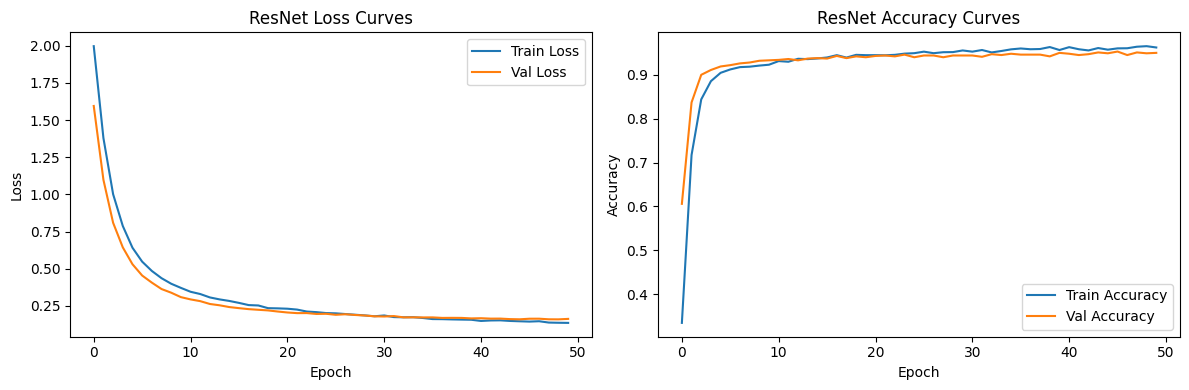

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses_resnet, label='Train Loss')
ax1.plot(val_losses_resnet, label='Val Loss')
ax1.set_title('ResNet Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs_resnet, label='Train Accuracy')
ax2.plot(val_accs_resnet, label='Val Accuracy')
ax2.set_title('ResNet Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('resnet_curves.png', dpi=150)
plt.show()

In [82]:
train_stl.classes

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

Correct predictions: ['horse', 'monkey']
Incorrect - True: ['truck', 'dog']
Incorrect - Pred: ['car', 'horse']


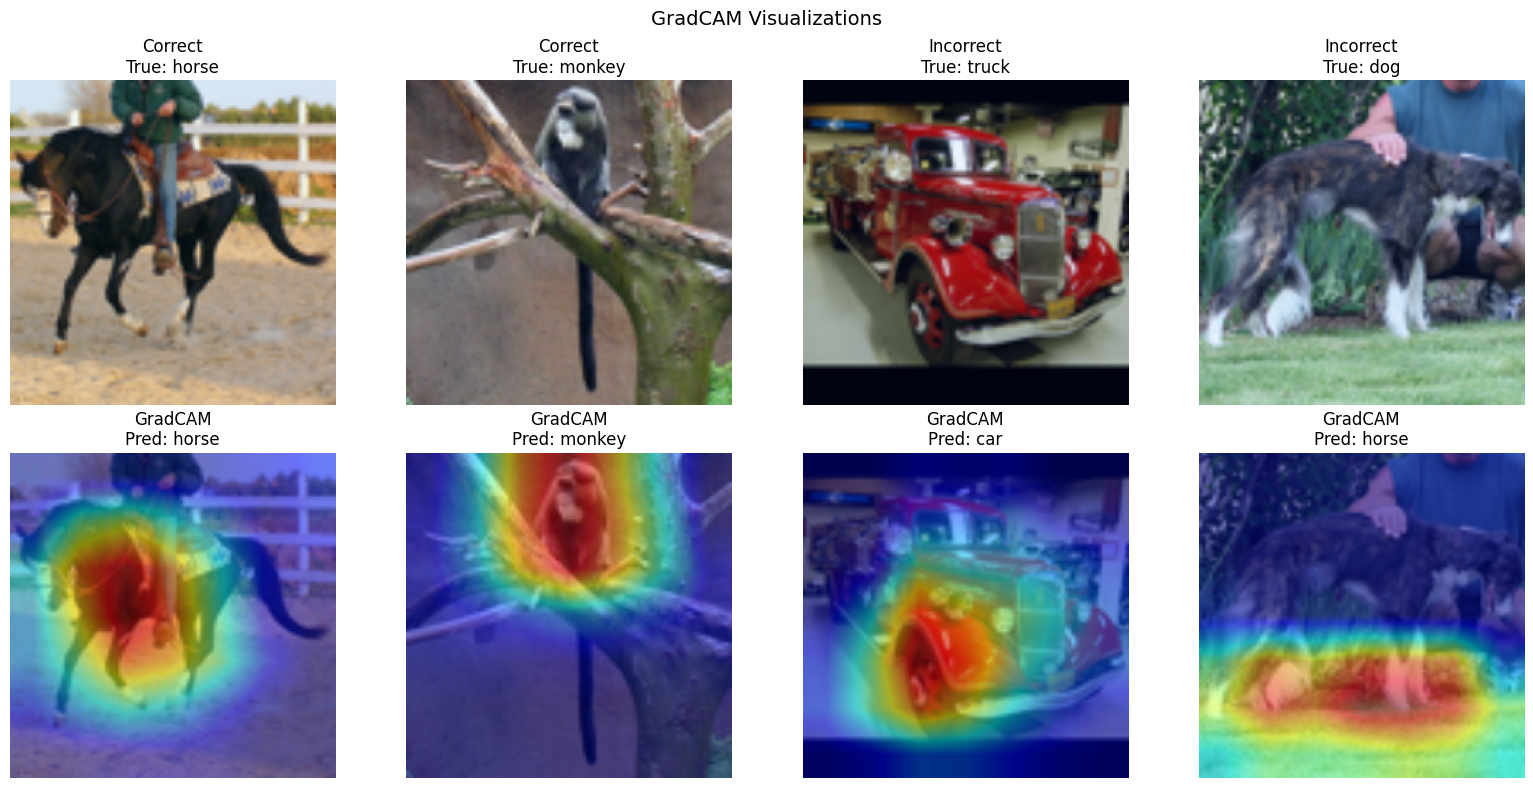

In [83]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

target_layer = [resnet.layer4[-1]]

dataiter = iter(test_stl_loader)
images, labels = next(dataiter)

classes = ['airplane', 'bird', 'car', 'cat', 'deer', 
           'dog', 'horse', 'monkey', 'ship', 'truck']

resnet.eval()
with torch.no_grad():
    outputs = resnet(images.to(device))
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()

correct_idx   = (predicted == labels).nonzero().flatten()[:2]
incorrect_idx = (predicted != labels).nonzero().flatten()[:2]
selected_idx  = torch.cat([correct_idx, incorrect_idx])

print("Correct predictions:", [classes[labels[i]] for i in correct_idx])
print("Incorrect - True:", [classes[labels[i]] for i in incorrect_idx])
print("Incorrect - Pred:", [classes[predicted[i]] for i in incorrect_idx])
target_layer = [resnet.layer4[-1]]
cam = GradCAM(model=resnet, target_layers=target_layer)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
titles = ['Correct', 'Correct', 'Incorrect', 'Incorrect']
for param in resnet.layer4.parameters():
    param.requires_grad = True
for i, idx in enumerate(selected_idx):
    img_tensor = images[idx].unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=img_tensor)[0]

    img_np = images[idx].permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = np.float32(img_np)

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"{titles[i]}\nTrue: {classes[labels[idx]]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(visualization)
    axes[1, i].set_title(f"GradCAM\nPred: {classes[predicted[idx]]}")
    axes[1, i].axis('off')

plt.suptitle('GradCAM Visualizations', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150)
plt.show()